# CAIRO run results review

This **state-agnostic** notebook reviews the outputs from the first four CAIRO simulation
runs for any given state and batch. Run it after a new batch is complete to sanity-check
inputs, verify bill arithmetic, and get an initial read on cross-subsidization and
bill-change patterns.

The first four runs (covering two upgrade levels × two supply configurations) produce
the master tables this notebook reads:

| Run pair | Upgrade | What it represents |
|----------|---------|--------------------|
| 1+2 | Upgrade 00 (baseline) | Current HVAC; delivery-only + delivery+supply combined |
| 3+4 | Upgrade 02 (HP upgrade) | All buildings given heat pumps; same two supply configs |

> **Demonstration state**: This notebook currently uses NY batch
> `ny_20260417a_r1-36` as a worked example.  
> **To review a different state, change `STATE` and `BATCH` in the Parameters cell
> and restart the kernel.**

---

## How to use for a new state

1. Change `STATE` (lowercase 2-letter abbreviation, e.g. `"ri"`, `"ct"`) and `BATCH`
   in the *Parameters* cell below.
2. Verify that `run_1+2` and `run_3+4` exist under
   `s3://data.sb/switchbox/cairo/outputs/hp_rates/<STATE>/all_utilities/<BATCH>/`.
3. Restart the kernel and run all cells (`Kernel → Restart & Run All`).
4. No other code changes are needed — all paths and column references are derived
   from `STATE` and `BATCH`.

---

## Notebook sections

| Section | What it covers |
|---------|---------------|
| **1 — Load data** | Read master bills and BAT tables from S3 for both run pairs |
| **2 — Input data quality checks (EDA)** | Utility assignments, heating-type composition, gas and electric spending distributions |
| **3 — Structural quality checks** | Schema validation, row counts, bill arithmetic identities |
| **4 — Baseline analysis (upgrade 00)** | Cross-subsidy table, BAT distribution, monthly bill pattern |
| **5 — Bill change analysis (upgrade 00 → 02)** | Quadrant bar chart, savings breakdown by heating type |

## Parameters

Change `STATE` and `BATCH` here to switch states. Everything else derives from these
two values.

In [38]:
from __future__ import annotations

import math
from typing import cast

import polars as pl
from IPython.display import display
from plotnine import (
    aes,
    coord_flip,
    facet_wrap,
    geom_col,
    geom_hline,
    geom_text,
    ggplot,
    guides,
    labs,
    position_dodge,
    position_stack,
    scale_fill_manual,
    scale_x_discrete,
    scale_y_continuous,
    theme,
)

from lib.plotnine import SB_COLORS, theme_switchbox

In [39]:
# ── Change these two values to review a different state or batch ─────────────
STATE = "ny"  # lowercase state abbreviation, e.g. "ri", "ct", "ma"
BATCH = "ny_20260417a_r1-36"
# ─────────────────────────────────────────────────────────────────────────────

S3_BASE = "s3://data.sb/switchbox/cairo/outputs/hp_rates"
RUN_PAIRS: dict[str, str] = {
    "Upgrade 00": "run_1+2",
    "Upgrade 02": "run_3+4",
}
DATASETS: dict[str, str] = {
    "bills": "comb_bills_year_target",
    "bat": "cross_subsidization_BAT_values",
}

BLDG_ID = "bldg_id"
UTILITY_COL = "sb.electric_utility"
GAS_UTILITY_COL = "sb.gas_utility"
HEATING_TYPE_COL = "postprocess_group.heating_type"
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
SCENARIO_ORDER = list(RUN_PAIRS)

# Human-readable labels for postprocess_group.heating_type values
HEATING_TYPE_LABELS: dict[str, str] = {
    "fossil_fuel": "Fossil fuel",
    "electrical_resistance": "Electric resistance",
    "heat_pump": "Existing heat pump",
}
# Display order for heating groups in charts and tables
HEATING_ORDER = ["Fossil fuel", "Electric resistance", "Existing heat pump", "Other"]

print(f"Reviewing {STATE.upper()} batch: {BATCH}")

Reviewing NY batch: ny_20260417a_r1-36


## Section 1: Load data

We load `comb_bills_year_target/` (monthly bills per building) and
`cross_subsidization_BAT_values/` (annual BAT metrics per building) for both run pairs.
Both datasets are Hive-partitioned on `sb.electric_utility`.

Each row in the **bills** table represents one building in one month (plus an `"Annual"`
summary row). Each row in the **BAT** table represents one building (annual only).
Schema details are in the AGENTS.md master-table documentation.

In [40]:
def master_path(run_pair: str, dataset: str) -> str:
    return f"{S3_BASE}/{STATE}/all_utilities/{BATCH}/{run_pair}/{dataset}/"


def load_master_table(run_pair: str, dataset: str) -> pl.DataFrame:
    return cast(
        pl.DataFrame,
        pl.scan_parquet(master_path(run_pair, dataset), hive_partitioning=True).collect(),
    )


bills_by_scenario: dict[str, pl.DataFrame] = {}
bat_by_scenario: dict[str, pl.DataFrame] = {}

for scenario, run_pair in RUN_PAIRS.items():
    bills_by_scenario[scenario] = load_master_table(run_pair, DATASETS["bills"])
    bat_by_scenario[scenario] = load_master_table(run_pair, DATASETS["bat"])

print("Loaded both scenarios.")
for scenario in SCENARIO_ORDER:
    b = bills_by_scenario[scenario]
    bt = bat_by_scenario[scenario]
    months_present = sorted(b.filter(pl.col("month") != "Annual")["month"].unique().to_list())
    print(f"  {scenario}: bills {b.shape}  |  BAT {bt.shape}  |  months: {months_present}")

Loaded both scenarios.
  Upgrade 00: bills (439270, 27)  |  BAT (33790, 35)  |  months: ['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
  Upgrade 02: bills (439270, 27)  |  BAT (33790, 35)  |  months: ['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


In [41]:
# Quick schema peek — useful when working with an unfamiliar batch
print("Bills schema:")
print(bills_by_scenario[SCENARIO_ORDER[0]].schema)
print("\nBAT schema:")
print(bat_by_scenario[SCENARIO_ORDER[0]].schema)

Bills schema:
Schema({'bldg_id': Int64, 'sb.gas_utility': String, 'upgrade': Int32, 'postprocess_group.has_hp': Boolean, 'postprocess_group.heating_type': String, 'postprocess_group.heating_type_v2': String, 'heats_with_electricity': Boolean, 'heats_with_natgas': Boolean, 'heats_with_oil': Boolean, 'heats_with_propane': Boolean, 'in.representative_income': Float64, 'in.hvac_cooling_partial_space_conditioning': String, 'month': String, 'weight': Float64, 'elec_fixed_charge': Float64, 'elec_delivery_bill': Float64, 'elec_supply_bill': Float64, 'elec_total_bill': Float64, 'passthrough_delivery': Float64, 'passthrough_supply': Float64, 'gas_fixed_charge': Float64, 'gas_volumetric_bill': Float64, 'gas_total_bill': Float64, 'propane_total_bill': Float64, 'oil_total_bill': Float64, 'energy_total_bill': Float64, 'sb.electric_utility': String})

BAT schema:
Schema({'bldg_id': Int64, 'sb.gas_utility': String, 'upgrade': Int32, 'postprocess_group.has_hp': Boolean, 'postprocess_group.heating_type'

## Section 2: Input data quality checks (EDA)

Before looking at bills and the BAT, we examine the raw inputs: how buildings are
distributed across utility territories, what their baseline heating systems are, and
what their gas and electric spending looks like. These checks catch assignment errors
and calibration anomalies early.

All EDA in this section uses upgrade 00 (`"Annual"` rows).

### 2a: Utility assignment

What fraction of buildings (and weighted households) are assigned to each electric and
gas utility? We expect the partition to align with each utility's approximate share of
the state's residential customers.

A large fraction of **null gas assignments** is normal — buildings that heat with
electricity, propane, or oil are not assigned a gas utility. Investigate if the null
fraction is surprisingly low in a territory with extensive gas infrastructure, or
surprisingly high in a gas-dense market.

In [42]:
annual_u0 = bills_by_scenario["Upgrade 00"].filter(pl.col("month") == "Annual")
total_bldgs = annual_u0.height
total_weighted = cast(float, annual_u0["weight"].sum())

print(f"Upgrade 00 — Annual rows: {total_bldgs:,} sample buildings, {total_weighted:,.0f} weighted households\n")

# Electric utility assignment
elec_assign = (
    annual_u0.with_columns(pl.col(UTILITY_COL).fill_null("(null)"))
    .group_by(UTILITY_COL)
    .agg(
        pl.len().alias("buildings"),
        pl.col("weight").sum().alias("weighted_households"),
    )
    .with_columns(
        (pl.col("weighted_households") / total_weighted * 100).round(1).alias("pct_of_total"),
    )
    .sort("weighted_households", descending=True)
    .rename({UTILITY_COL: "electric_utility"})
)
# Add summary row for electric (cast to match schema)
elec_assign_with_total = pl.concat(
    [
        elec_assign,
        pl.DataFrame(
            {
                "electric_utility": ["**TOTAL**"],
                "buildings": [elec_assign["buildings"].sum()],
                "weighted_households": [elec_assign["weighted_households"].sum()],
                "pct_of_total": [elec_assign["pct_of_total"].sum()],
            },
            schema=elec_assign.schema,
        ),
    ]
)
print("Electric utility assignment:")
display(elec_assign_with_total)

# Gas utility assignment
gas_assign = (
    annual_u0.with_columns(pl.col(GAS_UTILITY_COL).fill_null("(null — no gas service)"))
    .group_by(GAS_UTILITY_COL)
    .agg(
        pl.len().alias("buildings"),
        pl.col("weight").sum().alias("weighted_households"),
    )
    .with_columns(
        (pl.col("weighted_households") / total_weighted * 100).round(1).alias("pct_of_total"),
    )
    .sort("weighted_households", descending=True)
    .rename({GAS_UTILITY_COL: "gas_utility"})
)
# Add summary row for gas (cast to match schema)
gas_assign_with_total = pl.concat(
    [
        gas_assign,
        pl.DataFrame(
            {
                "gas_utility": ["**TOTAL**"],
                "buildings": [gas_assign["buildings"].sum()],
                "weighted_households": [gas_assign["weighted_households"].sum()],
                "pct_of_total": [gas_assign["pct_of_total"].sum()],
            },
            schema=gas_assign.schema,
        ),
    ]
)
print("\nGas utility assignment (null = no gas service / unassigned):")
display(gas_assign_with_total)

Upgrade 00 — Annual rows: 33,790 sample buildings, 7,251,938 weighted households

Electric utility assignment:


electric_utility,buildings,weighted_households,pct_of_total
str,u32,f64,f64
"""coned""",15435,3.0640e6,42.3
"""nimo""",6791,1.532294e6,21.1
"""psegli""",4427,1.0300e6,14.2
"""nyseg""",3682,792300.0,10.9
"""rge""",1444,351481.0,4.8
"""cenhud""",1182,270859.0,3.7
"""or""",829,211011.0,2.9
"""**TOTAL**""",33790,7.251938e6,99.9



Gas utility assignment (null = no gas service / unassigned):


gas_utility,buildings,weighted_households,pct_of_total
str,u32,f64,f64
"""(null — no gas service)""",8212,1.8038e6,24.9
"""coned""",6991,1.3887e6,19.1
"""kedny""",6418,1.2747e6,17.6
"""kedli""",2874,667484.048047,9.2
"""nimo""",2746,617985.707991,8.5
…,…,…,…
"""nyseg""",1581,348155.122257,4.8
"""rge""",1240,297109.964156,4.1
"""cenhud""",713,162382.688203,2.2


### Zero gas usage verification

Cross-check the gas utility assignment against ResStock annual gas consumption.
Buildings with zero annual gas consumption should align closely with the
"(null — no gas service)" category above, since gas utility assignment is gated
on `has_natgas_connection` (derived from nonzero gas consumption in
`load_curve_annual`).

Both metrics below are **unweighted building counts** for apples-to-apples
comparison. Small differences can arise from sampling variance or buildings with
minimal gas usage that round to zero in annual totals but are flagged as connected.

In [43]:
# Load ResStock metadata to check gas consumption
RESSTOCK_RELEASE = "res_2024_amy2018_2"
RESSTOCK_S3_BASE = "s3://data.sb/nrel/resstock"
GAS_CONSUMPTION_COL = "out.natural_gas.total.energy_consumption.kwh"

# Construct path to load_curve_annual for this state and upgrade 00
# Filename pattern: {STATE}_upgrade{UPGRADE}_metadata_and_annual_results.parquet
upgrade_padded = "00"
annual_filename = f"{STATE.upper()}_upgrade{upgrade_padded}_metadata_and_annual_results.parquet"
annual_path = f"{RESSTOCK_S3_BASE}/{RESSTOCK_RELEASE}/load_curve_annual/state={STATE.upper()}/upgrade={upgrade_padded}/{annual_filename}"

print(f"Loading ResStock annual load curves from:\n  {annual_path}\n")

# Load annual data and check for gas consumption column
annual_lf = pl.scan_parquet(annual_path)

# Select just bldg_id and gas consumption
gas_check = annual_lf.select([BLDG_ID, GAS_CONSUMPTION_COL]).collect()

# Count buildings with zero gas consumption
zero_gas = gas_check.filter(pl.col(GAS_CONSUMPTION_COL) == 0).height
nonzero_gas = gas_check.filter(pl.col(GAS_CONSUMPTION_COL) > 0).height
total_bldgs_annual = gas_check.height

pct_zero_gas = zero_gas / total_bldgs_annual * 100
pct_nonzero_gas = nonzero_gas / total_bldgs_annual * 100

print(f"Buildings with zero annual gas consumption: {zero_gas:,} / {total_bldgs_annual:,} ({pct_zero_gas:.1f}%)")
print(
    f"Buildings with nonzero annual gas consumption: {nonzero_gas:,} / {total_bldgs_annual:,} ({pct_nonzero_gas:.1f}%)"
)

# Compare to null gas utility assignment (unweighted building count)
try:
    null_gas_bldgs = gas_assign.filter(pl.col("gas_utility") == "(null — no gas service)")["buildings"][0]
    pct_null_gas_unweighted = null_gas_bldgs / total_bldgs * 100
    print(
        f"\nFor comparison, unweighted null gas utility assignment: {null_gas_bldgs:,} / {total_bldgs:,} ({pct_null_gas_unweighted:.1f}%)"
    )
    print(
        f"Difference (zero gas usage - null assignment): {pct_zero_gas - pct_null_gas_unweighted:.1f} percentage points"
    )
except (NameError, IndexError):
    print("\n(Run the utility assignment cell above first to compare with null gas assignment)")

Loading ResStock annual load curves from:
  s3://data.sb/nrel/resstock/res_2024_amy2018_2/load_curve_annual/state=NY/upgrade=00/NY_upgrade00_metadata_and_annual_results.parquet

Buildings with zero annual gas consumption: 8,212 / 33,790 (24.3%)
Buildings with nonzero annual gas consumption: 25,578 / 33,790 (75.7%)

For comparison, unweighted null gas utility assignment: 8,212 / 33,790 (24.3%)
Difference (zero gas usage - null assignment): 0.0 percentage points


### 2b: Heating type and fuel composition

What fraction of buildings heat with each fuel or technology under upgrade 00
(baseline)? This breakdown drives cross-subsidy and bill-change patterns throughout
the analysis.

The `postprocess_group.heating_type` column classifies buildings into three groups
used by CAIRO's post-processing:

- **Fossil fuel** — primary heat source is natural gas, oil, or propane
- **Electric resistance** — primary heat source is electric resistance
- **Existing heat pump** — already has a heat pump in the baseline

Baseline heating-type breakdown (upgrade 00):


/ebs/tmp/ipykernel_6500/1938810118.py:6: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


heating_label,buildings,weighted_households,heats_natgas,heats_oil,heats_propane,heats_electricity,pct_of_total
str,u32,f64,i32,i32,i32,i32,f64
"""Fossil fuel""",29554,6.3495e6,20201,7067,1280,0,87.6
"""Electric resistance""",3070,654504.118573,0,0,0,3070,9.0
"""Existing heat pump""",918,198368.027554,0,0,0,918,2.7
null,248,49529.864887,0,0,0,0,0.7


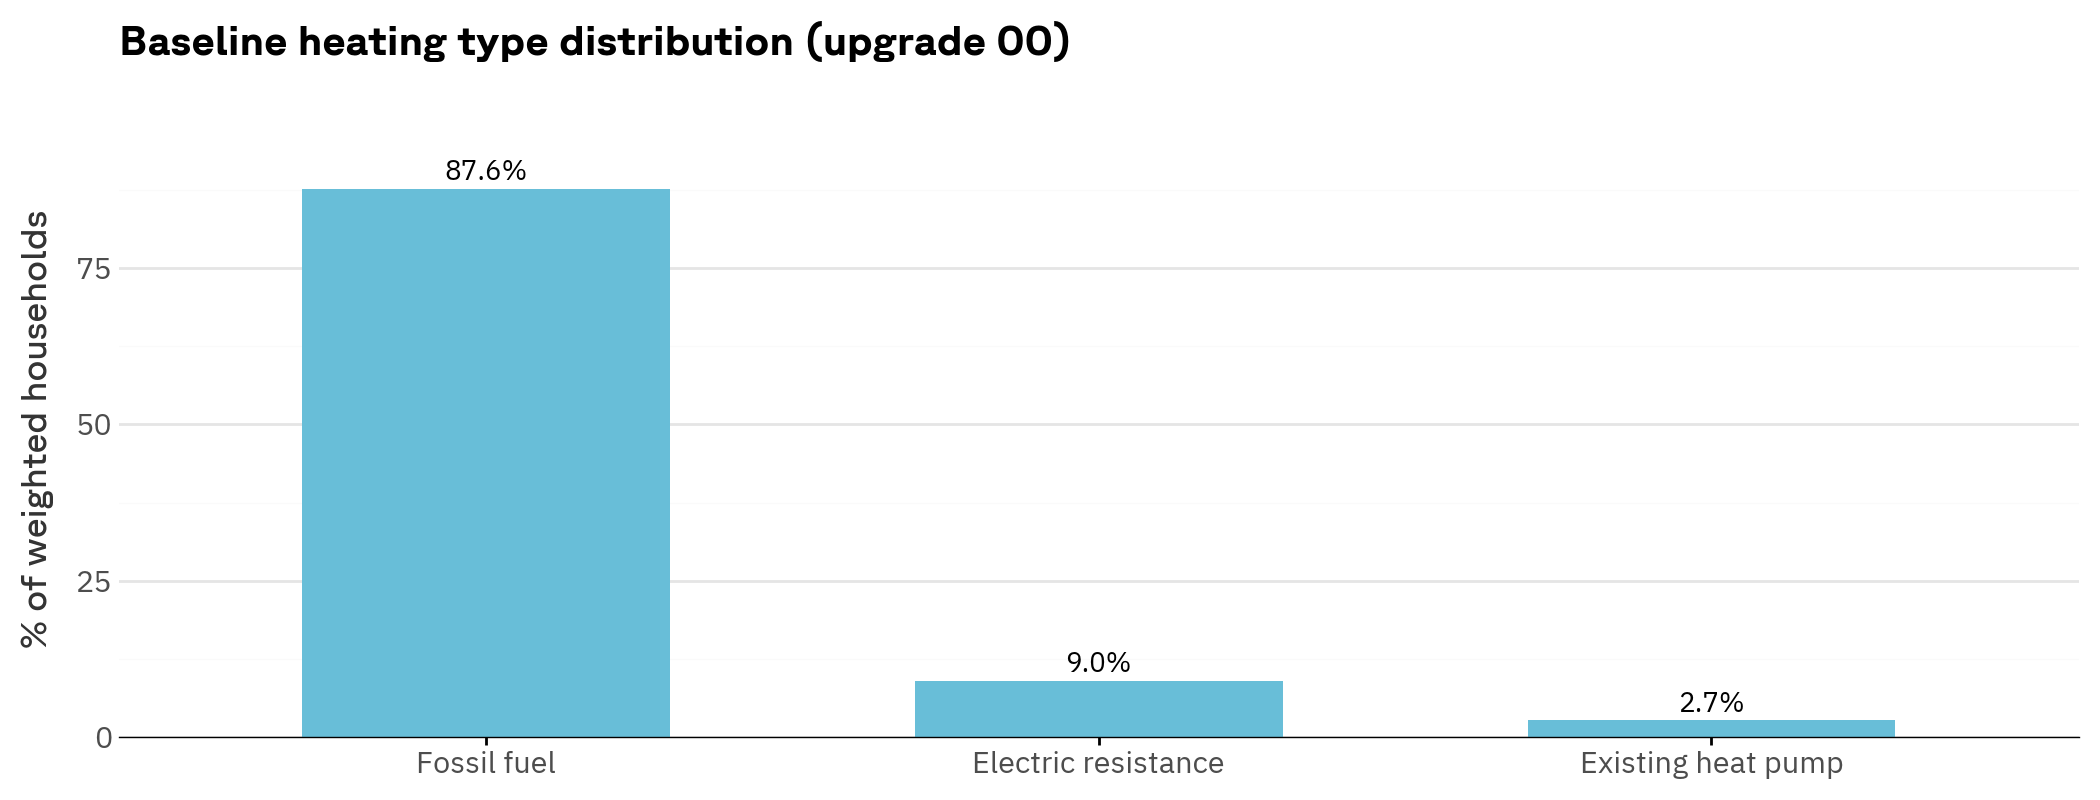

In [44]:
def add_heating_label(df: pl.DataFrame) -> pl.DataFrame:
    """Map postprocess_group.heating_type codes to human-readable labels."""
    return df.with_columns(
        pl.col(HEATING_TYPE_COL)
        .fill_null("Other")
        .replace(HEATING_TYPE_LABELS, default=pl.col(HEATING_TYPE_COL))
        .alias("heating_label")
    )


heating_df = add_heating_label(annual_u0)
heating_stats = (
    heating_df.group_by("heating_label")
    .agg(
        pl.len().alias("buildings"),
        pl.col("weight").sum().alias("weighted_households"),
        pl.col("heats_with_natgas").cast(pl.Int32).sum().alias("heats_natgas"),
        pl.col("heats_with_oil").cast(pl.Int32).sum().alias("heats_oil"),
        pl.col("heats_with_propane").cast(pl.Int32).sum().alias("heats_propane"),
        pl.col("heats_with_electricity").cast(pl.Int32).sum().alias("heats_electricity"),
    )
    .with_columns(
        (pl.col("weighted_households") / total_weighted * 100).round(1).alias("pct_of_total"),
    )
    .sort("weighted_households", descending=True)
)
print("Baseline heating-type breakdown (upgrade 00):")
display(heating_stats)

avail_order = [h for h in HEATING_ORDER if h in heating_df["heating_label"].unique().to_list()]
chart_data = (
    heating_stats.filter(pl.col("heating_label").is_in(avail_order))
    .with_columns(pl.col("heating_label").cast(pl.Enum(avail_order)))
    .sort("heating_label")
)
(
    ggplot(chart_data, aes(x="heating_label", y="pct_of_total"))
    + geom_col(fill=SB_COLORS["sky"], width=0.6)
    + geom_text(
        aes(label="pct_of_total"),
        format_string="{:.1f}%",
        nudge_y=0.4,
        size=10,
        va="bottom",
    )
    + scale_y_continuous(expand=(0, 0, 0.12, 0))
    + labs(
        x="",
        y="% of weighted households",
        title="Baseline heating type distribution (upgrade 00)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4))
)

### 2c: Annual gas spending by gas utility

Summary of annual gas bills (`gas_total_bill`, in dollars) for buildings with non-zero
gas bills, grouped by assigned gas utility.

> **Note**: `gas_total_bill` is a bill amount (dollars), not volumetric consumption
> (kWh or therms). For actual consumption data, cross-reference the ResStock monthly
> load curves column `out.natural_gas.total.energy_consumption`.

Implausibly wide min/max ranges, or extreme mean-to-median ratios, often trace to
incorrect tariff calibration or misassigned buildings.

In [45]:
gas_bill_stats = (
    annual_u0.filter(pl.col("gas_total_bill") > 0)
    .with_columns(pl.col(GAS_UTILITY_COL).fill_null("(null)"))
    .group_by(GAS_UTILITY_COL)
    .agg(
        pl.len().alias("buildings_with_gas_bill"),
        pl.col("weight").sum().alias("weighted_households"),
        pl.col("gas_total_bill").min().round(0).alias("min_gas_bill"),
        pl.col("gas_total_bill").max().round(0).alias("max_gas_bill"),
        pl.col("gas_total_bill").mean().round(0).alias("mean_gas_bill"),
        pl.col("gas_total_bill").median().round(0).alias("median_gas_bill"),
    )
    .sort("buildings_with_gas_bill", descending=True)
    .rename({GAS_UTILITY_COL: "gas_utility"})
)
print("Annual gas spending stats by gas utility\n(buildings with gas_total_bill > 0; unweighted mean/median):")
display(gas_bill_stats)

Annual gas spending stats by gas utility
(buildings with gas_total_bill > 0; unweighted mean/median):


gas_utility,buildings_with_gas_bill,weighted_households,min_gas_bill,max_gas_bill,mean_gas_bill,median_gas_bill
str,u32,f64,f64,f64,f64,f64
"""coned""",6991,1.3887e6,400.0,12166.0,1362.0,927.0
"""kedny""",6418,1.2747e6,251.0,7240.0,1462.0,1257.0
"""kedli""",2874,667484.048047,302.0,6189.0,1792.0,1756.0
"""nimo""",2746,617985.707991,265.0,4005.0,1063.0,998.0
"""nfg""",2421,540904.956926,238.0,3337.0,1007.0,957.0
"""nyseg""",1581,348155.122257,201.0,4667.0,1091.0,1005.0
"""rge""",1240,297109.964156,249.0,3639.0,1164.0,1098.0
"""cenhud""",713,162382.688203,325.0,7328.0,1374.0,968.0
"""or""",594,150773.083876,278.0,5743.0,1658.0,1449.0


### 2d: Annual electric bill by electric utility

Summary of annual total electric bills (`elec_total_bill = fixed + delivery volumetric
+ supply`), grouped by electric utility. The decomposition into fixed charge, delivery,
and supply components helps identify which tariff component is driving outliers.

Cross-check median values against published tariff rates for a rough sanity check.

In [46]:
elec_bill_stats = (
    annual_u0.group_by(UTILITY_COL)
    .agg(
        pl.len().alias("buildings"),
        pl.col("weight").sum().alias("weighted_households"),
        pl.col("elec_total_bill").min().round(0).alias("min_elec_total"),
        pl.col("elec_total_bill").max().round(0).alias("max_elec_total"),
        pl.col("elec_total_bill").mean().round(0).alias("mean_elec_total"),
        pl.col("elec_total_bill").median().round(0).alias("median_elec_total"),
        pl.col("elec_fixed_charge").median().round(0).alias("median_fixed"),
        pl.col("elec_delivery_bill").median().round(0).alias("median_delivery"),
        pl.col("elec_supply_bill").median().round(0).alias("median_supply"),
    )
    .sort("buildings", descending=True)
    .rename({UTILITY_COL: "electric_utility"})
)
print("Annual electric bill stats by electric utility (upgrade 00, unweighted mean/median):")
display(elec_bill_stats)

Annual electric bill stats by electric utility (upgrade 00, unweighted mean/median):


electric_utility,buildings,weighted_households,min_elec_total,max_elec_total,mean_elec_total,median_elec_total,median_fixed,median_delivery,median_supply
str,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""coned""",15435,3.0640e6,266.0,26915.0,1597.0,1251.0,255.0,608.0,388.0
"""nimo""",6791,1.532294e6,259.0,17161.0,1679.0,1408.0,215.0,578.0,615.0
"""psegli""",4427,1.0300e6,212.0,14787.0,2090.0,1900.0,197.0,841.0,858.0
"""nyseg""",3682,792300.0,286.0,19078.0,2042.0,1714.0,239.0,755.0,721.0
"""rge""",1444,351481.0,332.0,11209.0,1710.0,1399.0,288.0,510.0,604.0
"""cenhud""",1182,270859.0,368.0,17252.0,2388.0,2031.0,264.0,1064.0,702.0
"""or""",829,211011.0,349.0,14370.0,2045.0,1872.0,289.0,863.0,716.0


## Section 3: Structural quality checks

These checks catch common post-processing errors before any analysis proceeds:

- **Duplicate building IDs** — indicate a failed post-processing merge or join.
- **ID mismatches** — buildings that made it into one table but not the other.
- **Electric component arithmetic**:
  `elec_total_bill ≈ elec_fixed_charge + elec_delivery_bill + elec_supply_bill`
- **Energy total arithmetic**:
  `energy_total_bill ≈ elec_total_bill + gas_total_bill + propane_total_bill + oil_total_bill`
- **BAT identity**:
  `BAT_percustomer_total ≈ annual_bill_total − economic_burden_total − residual_share_total`

All assertions must pass before continuing. A failed assertion points to a specific
post-processing step to investigate.

In [47]:
qa_rows: list[dict[str, object]] = []

for scenario in SCENARIO_ORDER:
    bills = bills_by_scenario[scenario]
    bat = bat_by_scenario[scenario]
    annual = bills.filter(pl.col("month") == "Annual")

    elec_err = cast(
        float,
        annual.select(
            (
                pl.col("elec_total_bill")
                - pl.col("elec_fixed_charge")
                - pl.col("elec_delivery_bill")
                - pl.col("elec_supply_bill")
            )
            .abs()
            .max()
        ).item()
        or 0,
    )
    energy_err = cast(
        float,
        annual.select(
            (
                pl.col("energy_total_bill")
                - pl.col("elec_total_bill")
                - pl.col("gas_total_bill")
                - pl.col("propane_total_bill")
                - pl.col("oil_total_bill")
            )
            .abs()
            .max()
        ).item()
        or 0,
    )
    bat_err = cast(
        float,
        bat.select(
            (
                pl.col("BAT_percustomer_total")
                - pl.col("annual_bill_total")
                + pl.col("economic_burden_total")
                + pl.col("residual_share_total")
            )
            .abs()
            .max()
        ).item()
        or 0,
    )

    qa_rows.append(
        {
            "scenario": scenario,
            "bill rows": bills.height,
            "BAT rows": bat.height,
            "annual bill bldgs": annual[BLDG_ID].n_unique(),
            "BAT bldgs": bat[BLDG_ID].n_unique(),
            "duplicate annual IDs": annual.height - annual[BLDG_ID].n_unique(),
            "duplicate BAT IDs": bat.height - bat[BLDG_ID].n_unique(),
            "bill IDs missing from BAT": annual.join(bat.select(BLDG_ID), on=BLDG_ID, how="anti").height,
            "BAT IDs missing from bills": bat.join(annual.select(BLDG_ID), on=BLDG_ID, how="anti").height,
            "max elec component error": elec_err,
            "max energy component error": energy_err,
            "max BAT identity error": bat_err,
        }
    )

qa = pl.DataFrame(qa_rows)
display(qa)

assert qa["duplicate annual IDs"].sum() == 0, "Duplicate annual bill IDs found"
assert qa["duplicate BAT IDs"].sum() == 0, "Duplicate BAT IDs found"
assert qa["bill IDs missing from BAT"].sum() == 0, "Bill IDs missing from BAT table"
assert qa["BAT IDs missing from bills"].sum() == 0, "BAT IDs missing from bills table"
assert cast(float, qa["max elec component error"].max()) < 0.01, "Electric component arithmetic mismatch"
assert cast(float, qa["max energy component error"].max()) < 0.01, "Energy total arithmetic mismatch"
assert cast(float, qa["max BAT identity error"].max()) < 0.01, "BAT identity check failed"
print("All structural checks passed.")

scenario,bill rows,BAT rows,annual bill bldgs,BAT bldgs,duplicate annual IDs,duplicate BAT IDs,bill IDs missing from BAT,BAT IDs missing from bills,max elec component error,max energy component error,max BAT identity error
str,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64
"""Upgrade 00""",439270,33790,33790,33790,0,0,0,0,9.0949e-13,1.8190e-12,1.1369e-12
"""Upgrade 02""",439270,33790,33790,33790,0,0,0,0,9.0949e-13,1.7053e-12,4.6566e-10


All structural checks passed.


## Section 4: Baseline analysis (upgrade 00, runs 1+2)

This section uses the upgrade 00 run pair (runs 1+2), representing the current state:
each building is on its existing heating system with today's electric and gas rates.

### 4a: Weighted statistics helpers

We define weighted mean and weighted quantile here so they are available to all
subsequent cells.

In [48]:
def weighted_mean(df: pl.DataFrame, value: str, weight: str = "weight") -> float:
    """Weighted arithmetic mean."""
    valid = df.filter(pl.col(value).is_not_null() & pl.col(weight).is_not_null())
    wsum = cast(float, valid[weight].sum())
    if valid.is_empty() or wsum == 0:
        return float("nan")
    return cast(float, (valid[value] * valid[weight]).sum()) / wsum


def weighted_quantile(
    df: pl.DataFrame,
    value: str,
    q: float,
    weight: str = "weight",
) -> float:
    """Weighted quantile via cumulative weight sort."""
    valid = df.filter(pl.col(value).is_not_null() & pl.col(weight).is_not_null()).sort(value)
    wsum = cast(float, valid[weight].sum())
    if valid.is_empty() or wsum == 0:
        return float("nan")
    return float(valid.filter(pl.col(weight).cum_sum() >= wsum * q)[value][0])

### 4b: Cross-subsidization table

The **Bill Alignment Test (BAT)** measures whether each customer pays more or less than
their cost of service. A positive BAT means the customer **overpays** (they
cross-subsidize others). A negative BAT means they **underpay** (they receive a
cross-subsidy from others).

The table below shows each heating-type group's share of customers, electric delivery
revenue, cost of service, and total overpayment. Under flat volumetric rates, heat pump
and electric resistance customers typically overpay because they use more electricity
(and therefore pay more delivery cost per unit) than fossil fuel customers, whose
delivery cost does not scale with their gas consumption.

Column definitions:

- **% of delivery revenue** — group's weighted share of annual delivery bill revenue
- **% of cost of service** — group's weighted share of annual cost of service
  (`economic_burden_total + residual_share_total`)
- **Total overpayment** — weighted sum of positive BAT values within the group
- **% of system overpayment** — group's share of the system's total cross-subsidy
- **Mean BAT** — weighted mean BAT per customer (positive = overpaying)

In [49]:
bat_u0 = add_heating_label(bat_by_scenario["Upgrade 00"]).with_columns(
    (pl.col("economic_burden_total") + pl.col("residual_share_total")).alias("cost_of_service"),
)

_total_customers = cast(float, bat_u0["weight"].sum())
_total_revenue = cast(float, (bat_u0["annual_bill_total"] * bat_u0["weight"]).sum())
_total_cos = cast(float, (bat_u0["cost_of_service"] * bat_u0["weight"]).sum())
_total_overpay = cast(
    float,
    bat_u0.filter(pl.col("BAT_percustomer_total") > 0)
    .select((pl.col("BAT_percustomer_total") * pl.col("weight")).sum())
    .item()
    or 0,
)

_avail_groups = [h for h in HEATING_ORDER if h in bat_u0["heating_label"].unique().to_list()]
_groups: dict[str, pl.DataFrame] = {"All customers": bat_u0} | {
    label: bat_u0.filter(pl.col("heating_label") == label) for label in _avail_groups
}

cs_rows: list[dict[str, object]] = []
for name, gdf in _groups.items():
    gdf_over = gdf.filter(pl.col("BAT_percustomer_total") > 0)
    g_cust = cast(float, gdf["weight"].sum())
    g_rev = cast(float, (gdf["annual_bill_total"] * gdf["weight"]).sum())
    g_cos = cast(float, (gdf["cost_of_service"] * gdf["weight"]).sum())
    g_over = cast(
        float,
        gdf_over.select((pl.col("BAT_percustomer_total") * pl.col("weight")).sum()).item() or 0,
    )
    cs_rows.append(
        {
            "Customer group": name,
            "% of customers": round(g_cust / _total_customers * 100, 1),
            "% of delivery revenue": round(g_rev / _total_revenue * 100, 1),
            "% of cost of service": round(g_cos / _total_cos * 100, 1),
            "Total overpayment ($M/yr)": round(g_over / 1e6, 1),
            "% of system overpayment": (round(g_over / _total_overpay * 100, 1) if _total_overpay else float("nan")),
            "Mean BAT ($/yr)": round(weighted_mean(gdf, "BAT_percustomer_total"), 0),
        }
    )

cs_table = pl.DataFrame(cs_rows)
print("Cross-subsidization by customer group (upgrade 00, annual, weighted):")
display(cs_table)

/ebs/tmp/ipykernel_6500/1938810118.py:6: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


Cross-subsidization by customer group (upgrade 00, annual, weighted):


Customer group,% of customers,% of delivery revenue,% of cost of service,Total overpayment ($M/yr),% of system overpayment,Mean BAT ($/yr)
str,f64,f64,f64,f64,f64,f64
"""All customers""",100.0,100.0,100.0,1760.0,100.0,-0.0
"""Fossil fuel""",87.6,77.0,83.3,867.8,49.3,-127.0
"""Electric resistance""",9.0,17.2,12.3,684.9,38.9,970.0
"""Existing heat pump""",2.7,5.3,3.9,205.7,11.7,935.0


### 4c: Delivery BAT by heating type (upgrade 00 vs. upgrade 02)

The grouped bar chart shows weighted mean total BAT across both upgrade scenarios.
Under upgrade 00 (current rates, baseline HVAC), the direction and magnitude of the
BAT for each heating group set the baseline. Under upgrade 02 (same rates, all
buildings now have heat pumps), the BAT distribution shifts as load profiles change.

Weighted mean total BAT ($/yr) by heating type and scenario:


/ebs/tmp/ipykernel_6500/1938810118.py:6: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


scenario,heating_label,mean_bat_total,mean_bat_delivery,mean_bat_supply,median_bat_total,pct_overpaying
str,str,f64,f64,f64,f64,f64
"""Upgrade 00""","""Fossil fuel""",-127.147981,-114.601156,-12.546825,-216.614061,31.387175
"""Upgrade 00""","""Electric resistance""",970.407277,872.593116,97.814161,488.418388,73.5572
"""Upgrade 00""","""Existing heat pump""",935.496001,854.704502,80.7915,465.815976,67.941825
"""Upgrade 02""","""Fossil fuel""",-965993.860424,-967161.62557,1167.765146,-649682.46791,0.0
"""Upgrade 02""","""Electric resistance""",-930564.235766,-931658.265235,1094.02947,-649856.981097,0.0
"""Upgrade 02""","""Existing heat pump""",-1.1065e6,-1.1077e6,1165.278772,-650202.31266,0.0


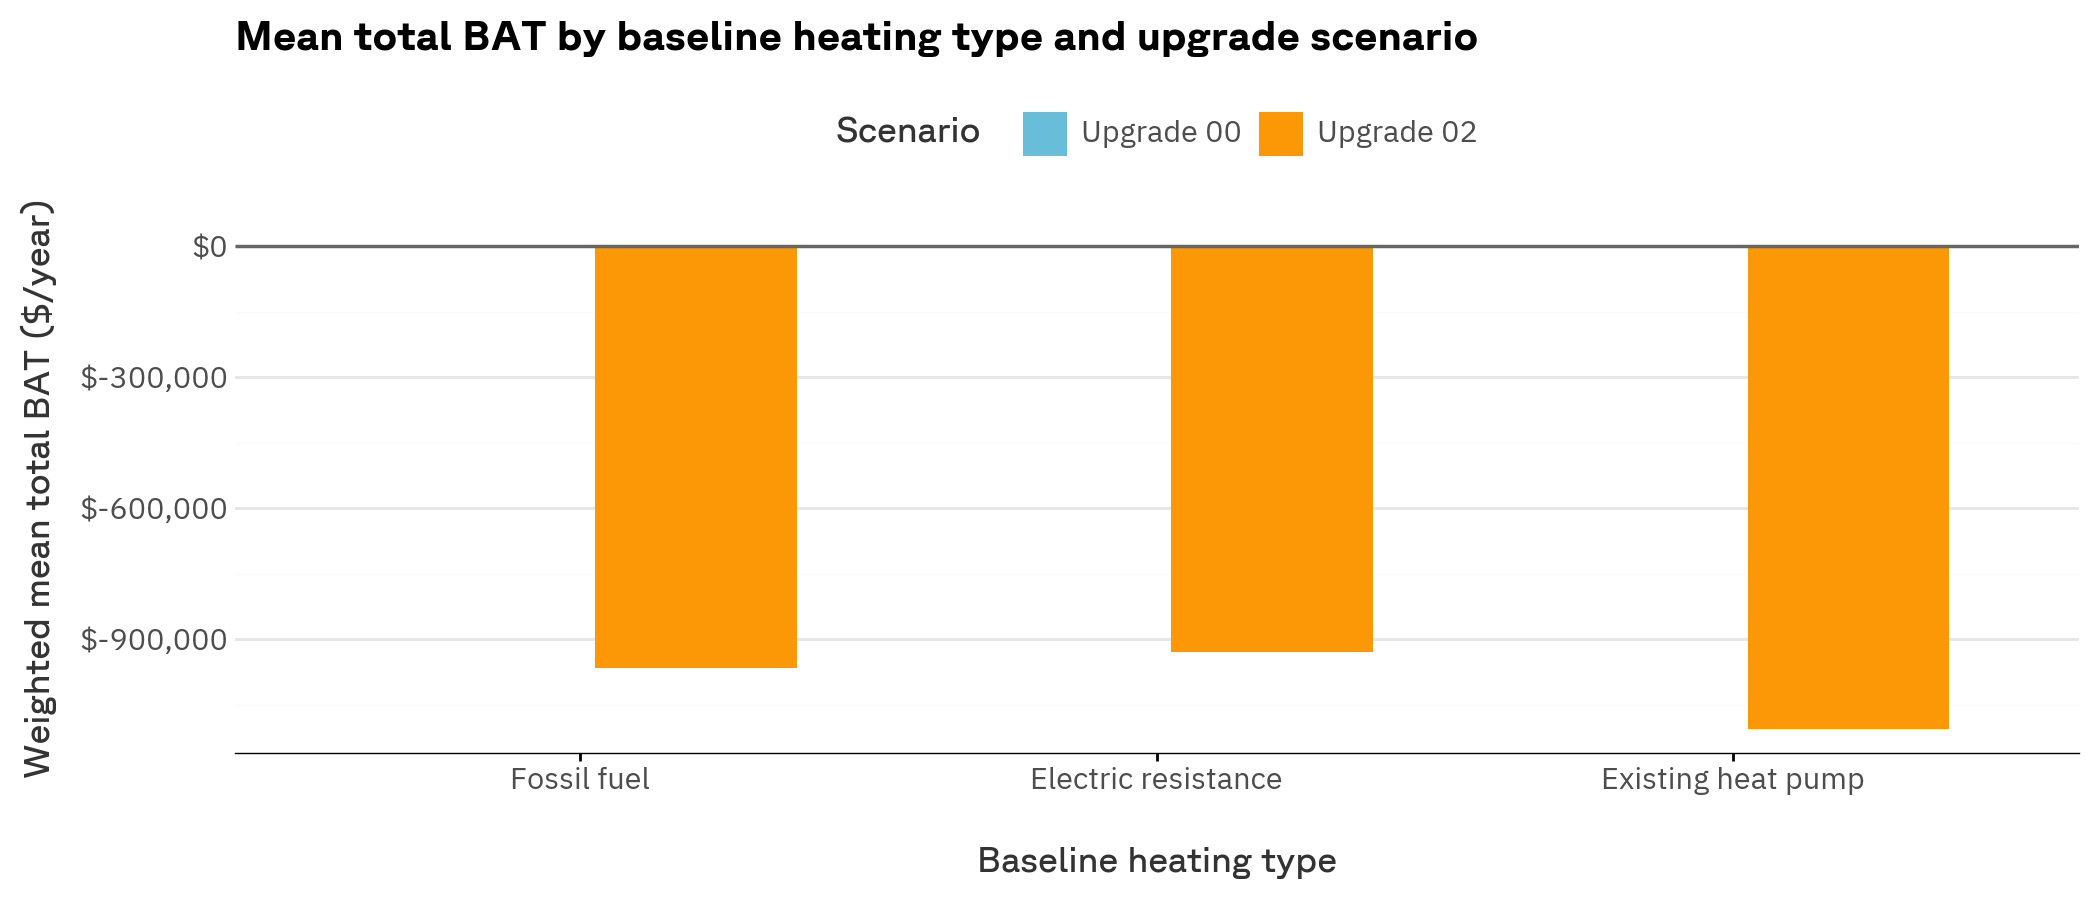

In [50]:
bat_summary_rows: list[dict[str, object]] = []
for scenario in SCENARIO_ORDER:
    bat_s = add_heating_label(bat_by_scenario[scenario])
    avail = [h for h in HEATING_ORDER if h in bat_s["heating_label"].unique().to_list()]
    for group in avail:
        gdf = bat_s.filter(pl.col("heating_label") == group)
        total_w = cast(float, gdf["weight"].sum())
        bat_summary_rows.append(
            {
                "scenario": scenario,
                "heating_label": group,
                "mean_bat_total": weighted_mean(gdf, "BAT_percustomer_total"),
                "mean_bat_delivery": weighted_mean(gdf, "BAT_percustomer_delivery"),
                "mean_bat_supply": weighted_mean(gdf, "BAT_percustomer_supply"),
                "median_bat_total": weighted_quantile(gdf, "BAT_percustomer_total", 0.5),
                "pct_overpaying": (
                    cast(
                        float,
                        gdf.filter(pl.col("BAT_percustomer_total") > 0)["weight"].sum(),
                    )
                    / total_w
                    * 100
                ),
            }
        )

bat_summary = pl.DataFrame(bat_summary_rows)
print("Weighted mean total BAT ($/yr) by heating type and scenario:")
display(
    bat_summary.select(
        "scenario",
        "heating_label",
        "mean_bat_total",
        "mean_bat_delivery",
        "mean_bat_supply",
        "median_bat_total",
        "pct_overpaying",
    )
)

avail_bat = [h for h in HEATING_ORDER if h in bat_summary["heating_label"].unique().to_list()]
bat_plot_data = bat_summary.with_columns(
    pl.col("heating_label").cast(pl.Enum(avail_bat)),
    pl.col("scenario").cast(pl.Enum(SCENARIO_ORDER)),
)

(
    ggplot(bat_plot_data, aes(x="heating_label", y="mean_bat_total", fill="scenario"))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + geom_hline(yintercept=0, color="#666666", size=0.7)
    + scale_fill_manual(values={"Upgrade 00": SB_COLORS["sky"], "Upgrade 02": SB_COLORS["carrot"]})
    + scale_y_continuous(labels=lambda xs: [f"${x:,.0f}" for x in xs])
    + labs(
        x="Baseline heating type",
        y="Weighted mean total BAT ($/year)",
        fill="Scenario",
        title="Mean total BAT by baseline heating type and upgrade scenario",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4.5), legend_position="top")
)

### 4d: Monthly bill pattern

Weighted-mean household energy bills by month, before (upgrade 00) and after (upgrade 02)
the heat pump retrofit. Winter months show the largest divergence: gas-heated homes have
high gas bills under upgrade 00, while after the retrofit (upgrade 02) gas bills
effectively drop to zero and electric bills increase due to heat pump load.

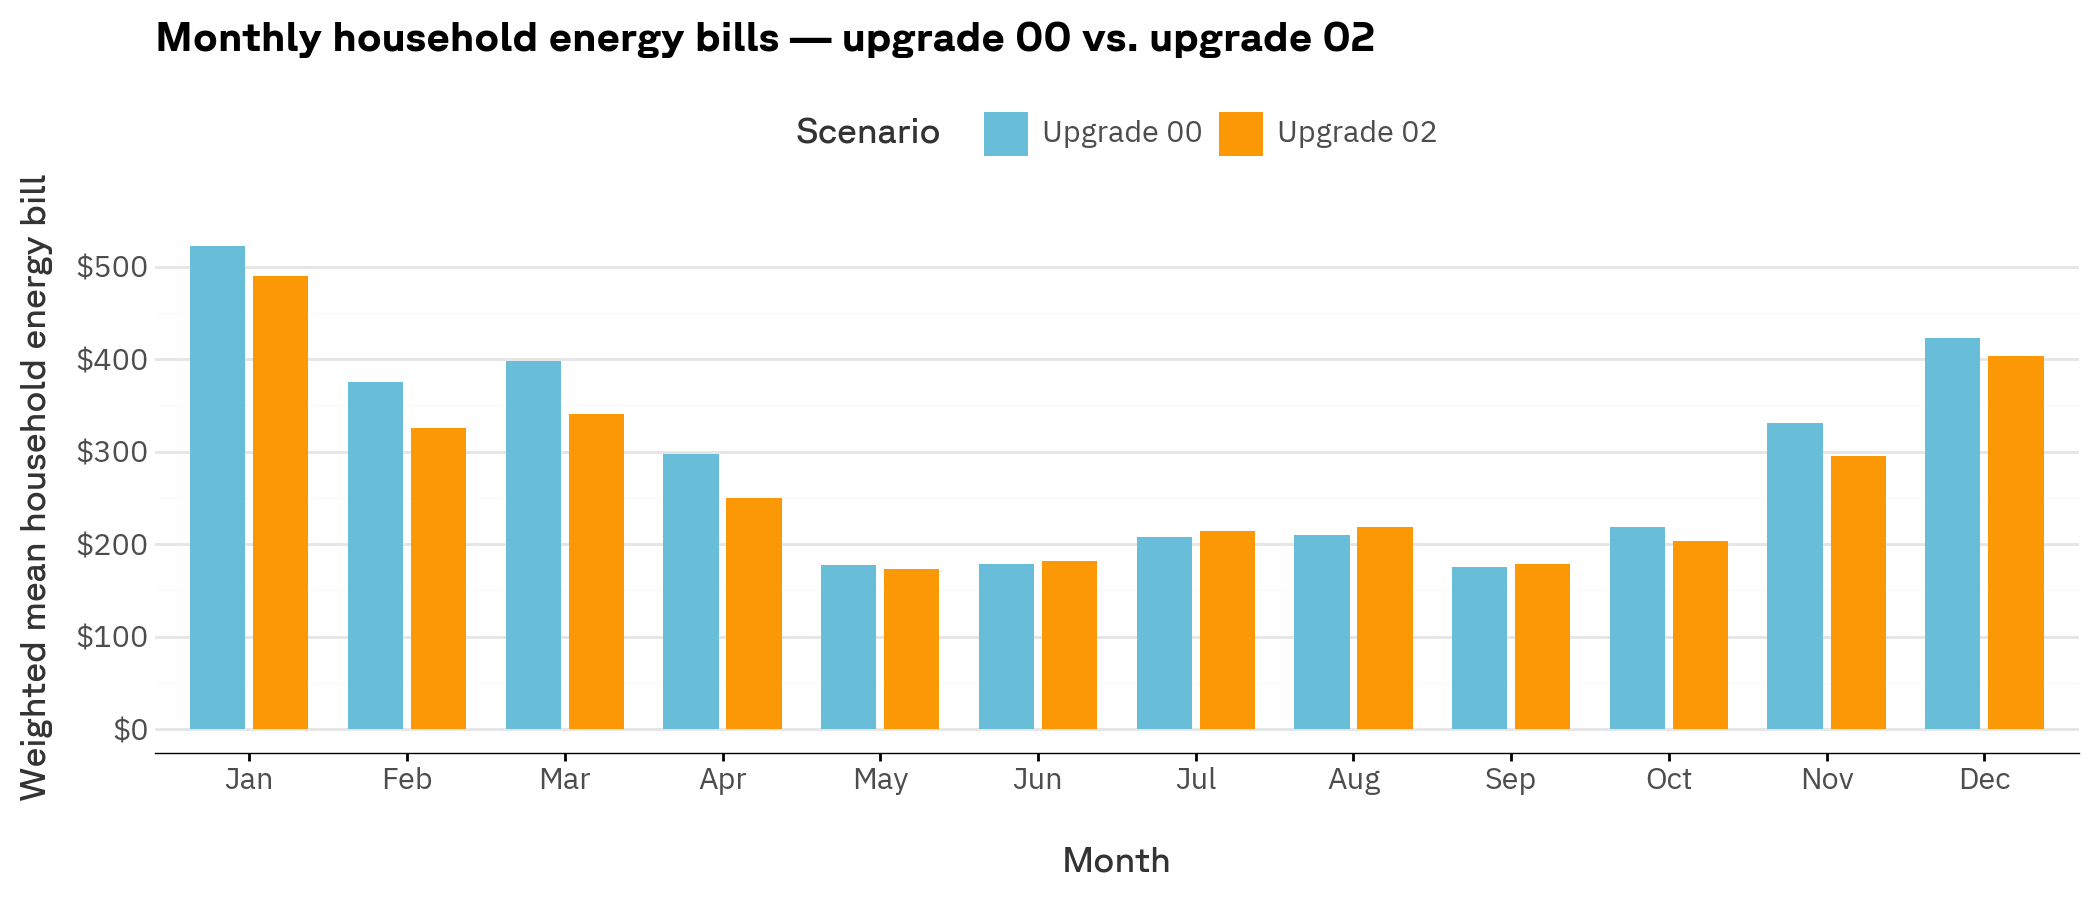

In [51]:
monthly_rows: list[dict[str, object]] = []
for scenario in SCENARIO_ORDER:
    monthly = bills_by_scenario[scenario].filter(pl.col("month").is_in(MONTH_ORDER))
    for month in MONTH_ORDER:
        mdf = monthly.filter(pl.col("month") == month)
        if mdf.is_empty():
            continue
        monthly_rows.append(
            {
                "scenario": scenario,
                "month": month,
                "energy_bill": weighted_mean(mdf, "energy_total_bill"),
                "elec_bill": weighted_mean(mdf, "elec_total_bill"),
            }
        )

monthly_df = pl.DataFrame(monthly_rows).with_columns(
    pl.col("scenario").cast(pl.Enum(SCENARIO_ORDER)),
    pl.col("month").cast(pl.Enum(MONTH_ORDER)),
)

(
    ggplot(monthly_df, aes(x="month", y="energy_bill", fill="scenario"))
    + geom_col(position=position_dodge(width=0.8), width=0.7)
    + scale_fill_manual(values={"Upgrade 00": SB_COLORS["sky"], "Upgrade 02": SB_COLORS["carrot"]})
    + scale_x_discrete(limits=MONTH_ORDER)
    + scale_y_continuous(labels=lambda xs: [f"${x:,.0f}" for x in xs])
    + labs(
        x="Month",
        y="Weighted mean household energy bill",
        fill="Scenario",
        title="Monthly household energy bills — upgrade 00 vs. upgrade 02",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 4.5), legend_position="top")
)

## Section 5: Bill change analysis (upgrade 00 → upgrade 02)

This section compares each building's annual energy bill **before** (upgrade 00) and
**after** (upgrade 02) the heat pump retrofit.

Bill change δ = `bill_after − bill_before`; negative δ means savings.

Buildings are classified by their **upgrade 00** heating type throughout — i.e., by
the baseline fuel they would be replacing.

In [52]:
# ── Quadrant definitions (from analysis.qmd) ──────────────────────────────────

QUADRANT_COLORS: dict[str, str] = {
    "savings > $1k": "#1b5e20",
    "savings $0-1k": "#81c784",
    "losses $0-1k": "#ef9a9a",
    "losses > $1k": "#b71c1c",
}
QUADRANT_ORDER = list(QUADRANT_COLORS.keys())
QUADRANT_LABELS: dict[str, str] = {
    "losses > $1k": "LOSE > $1K",
    "losses $0-1k": "LOSE $0-1K",
    "savings $0-1k": "SAVE $0-1K",
    "savings > $1k": "SAVE > $1K",
}


def quadrant_pcts(df: pl.DataFrame) -> dict[str, float]:
    """Weighted % of households in each bill-change quadrant (df must have 'delta' + 'weight')."""
    total = cast(float, df["weight"].sum())
    return {
        "savings > $1k": cast(float, df.filter(pl.col("delta") < -1000)["weight"].sum()) / total * 100,
        "savings $0-1k": cast(
            float,
            df.filter((pl.col("delta") >= -1000) & (pl.col("delta") < 0))["weight"].sum(),
        )
        / total
        * 100,
        "losses $0-1k": cast(
            float,
            df.filter((pl.col("delta") >= 0) & (pl.col("delta") < 1000))["weight"].sum(),
        )
        / total
        * 100,
        "losses > $1k": cast(float, df.filter(pl.col("delta") >= 1000)["weight"].sum()) / total * 100,
    }


# ── Bill change dataframe ──────────────────────────────────────────────────────

bill_delta = (
    add_heating_label(
        bills_by_scenario["Upgrade 00"]
        .filter(pl.col("month") == "Annual")
        .select(
            BLDG_ID,
            UTILITY_COL,
            "weight",
            HEATING_TYPE_COL,
            "heats_with_natgas",
            "heats_with_oil",
            "heats_with_propane",
            pl.col("energy_total_bill").alias("bill_before"),
        )
    )
    .join(
        bills_by_scenario["Upgrade 02"]
        .filter(pl.col("month") == "Annual")
        .select(BLDG_ID, pl.col("energy_total_bill").alias("bill_after")),
        on=BLDG_ID,
        how="inner",
        validate="1:1",
    )
    .with_columns((pl.col("bill_after") - pl.col("bill_before")).alias("delta"))
)

avail_heating = [h for h in HEATING_ORDER if h in bill_delta["heating_label"].unique().to_list()]
n_save = bill_delta.filter(pl.col("delta") < 0).height
pct_save = n_save / bill_delta.height * 100
print(f"Bill delta computed for {bill_delta.height:,} buildings.  {pct_save:.1f}% have negative delta (savings).")
print(f"Heating groups: {avail_heating}")

Bill delta computed for 33,790 buildings.  54.1% have negative delta (savings).
Heating groups: ['Fossil fuel', 'Electric resistance', 'Existing heat pump']


/ebs/tmp/ipykernel_6500/1938810118.py:6: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)


### 5a: Quadrant bar chart by heating type

Each bar shows the percentage of weighted households in four outcome bins:

| Bin | Definition |
|-----|------------|
| SAVE > $1K | Annual energy bill decreases by more than $1,000 |
| SAVE $0-1K | Annual energy bill decreases by $0–$1,000 |
| LOSE $0-1K | Annual energy bill increases by $0–$1,000 |
| LOSE > $1K | Annual energy bill increases by more than $1,000 |

A bar leaning heavily green indicates that most households in that group would save
money by switching to a heat pump under current rates.

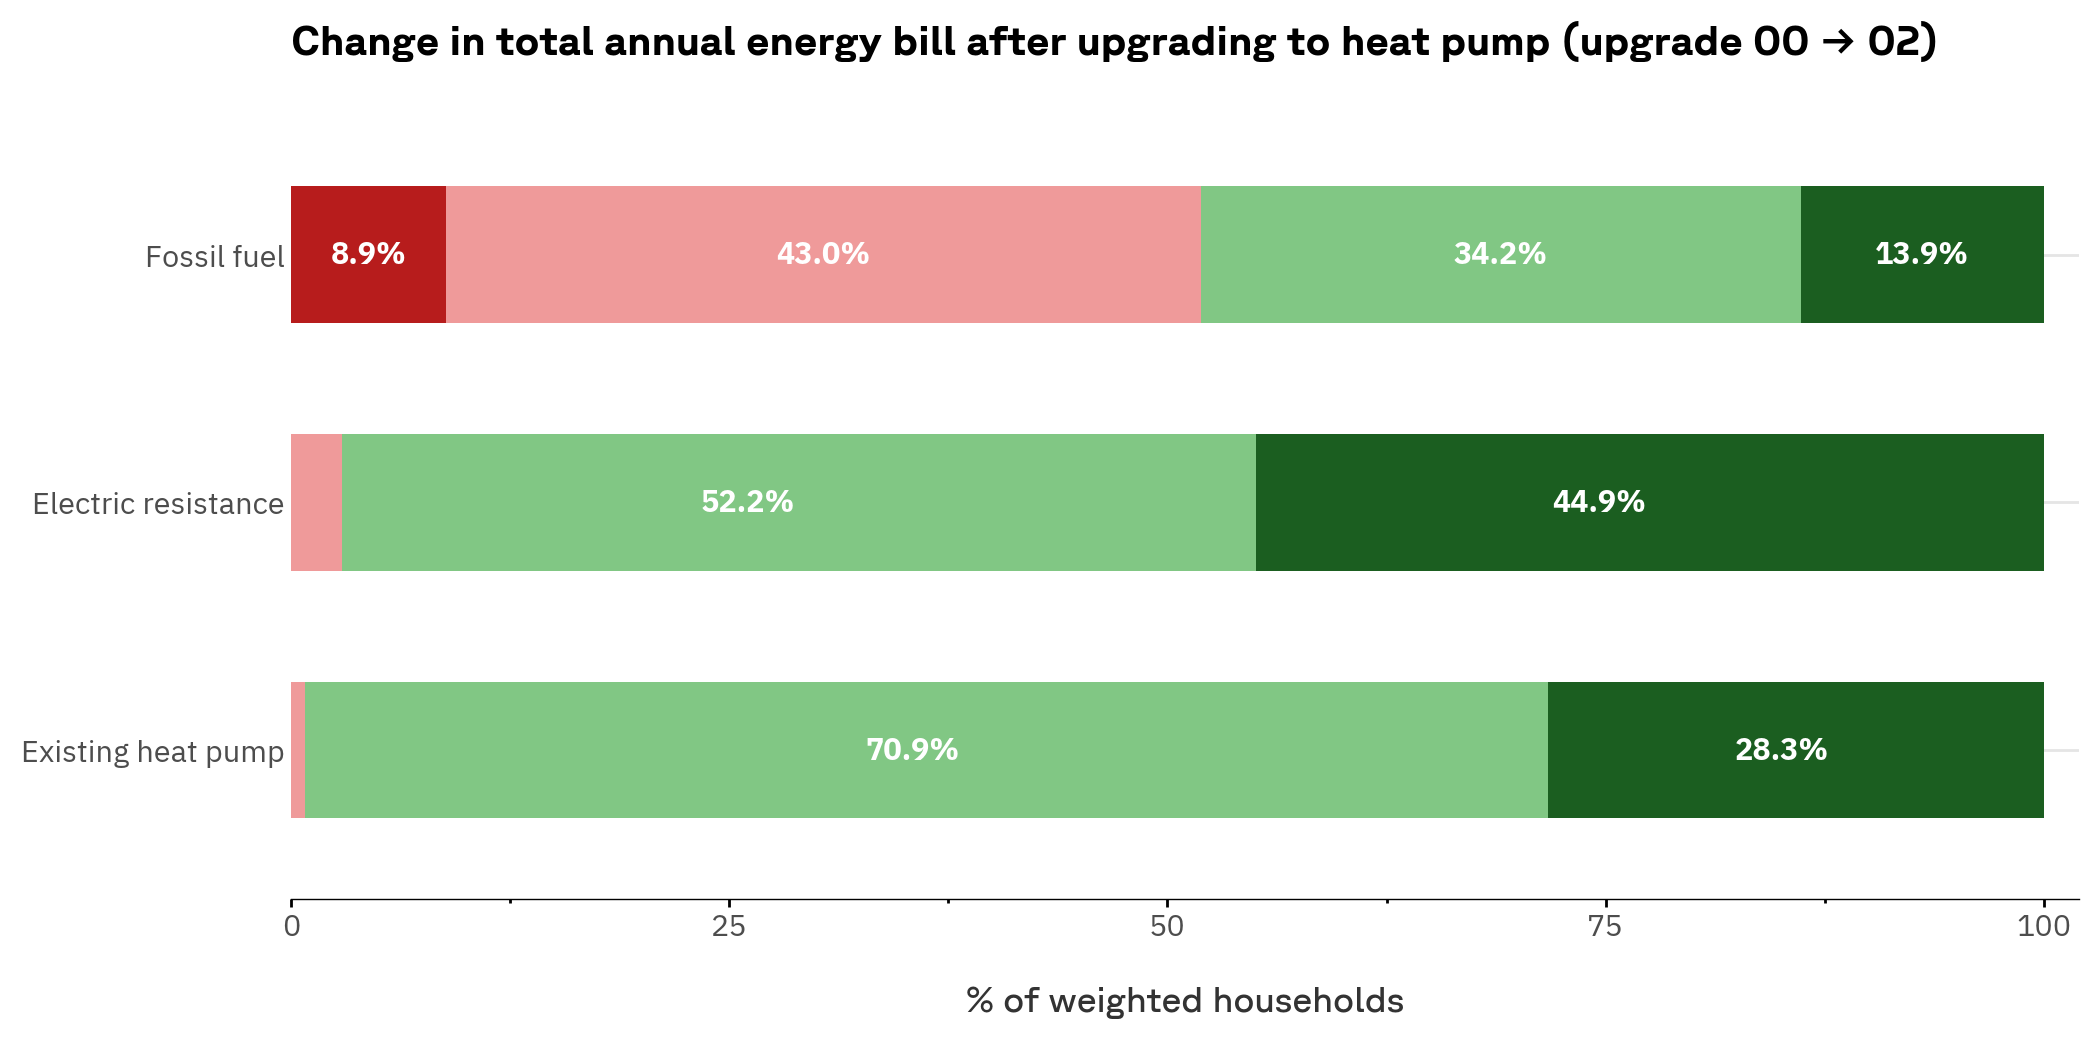

In [53]:
qb_records: list[dict[str, object]] = []
for group in avail_heating:
    gdf = bill_delta.filter(pl.col("heating_label") == group)
    pct = quadrant_pcts(gdf)
    for q in QUADRANT_ORDER:
        qb_records.append({"heating_label": group, "quadrant": q, "pct": pct[q]})

qb_plot = pl.DataFrame(qb_records).with_columns(
    pl.col("heating_label").cast(pl.Enum(list(reversed(avail_heating)))),
    pl.col("quadrant").cast(pl.Enum(QUADRANT_ORDER)),
)

(
    ggplot(qb_plot, aes(x="heating_label", y="pct", fill="quadrant"))
    + geom_col(position="stack", width=0.55)
    + geom_text(
        mapping=aes(label="pct"),
        data=qb_plot.filter(pl.col("pct") >= 3),
        position=position_stack(vjust=0.5),
        format_string="{:.1f}%",
        color="white",
        size=11,
        fontweight="bold",
    )
    + scale_fill_manual(values=QUADRANT_COLORS, breaks=QUADRANT_ORDER)
    + scale_y_continuous(expand=(0, 0, 0.02, 0))
    + coord_flip()
    + guides(fill=False)
    + labs(
        x="",
        y="% of weighted households",
        title="Change in total annual energy bill after upgrading to heat pump (upgrade 00 → 02)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, max(3.5, 1.0 + 1.4 * len(avail_heating))))
)

### 5b: Savings breakdown table

The table below shows the fraction of weighted households in each savings/loss bin,
broken out by baseline heating type, plus weighted mean and median bill changes.
The bin boundaries ($0, $1k, $2k) are the same as in the quadrant bars above, with
an additional `Save > $2k/yr` bin to capture large savings from oil/propane retrofits.

In [54]:
SAVE_BINS: list[tuple[float, float, str]] = [
    (-float("inf"), -2000, "Save > $2k/yr"),
    (-2000, -1000, "Save $1k-$2k/yr"),
    (-1000, 0, "Save $0-$1k/yr"),
    (0, 1000, "Lose $0-$1k/yr"),
    (1000, float("inf"), "Lose > $1k/yr"),
]

savings_rows: list[dict[str, object]] = []
for group in avail_heating:
    gdf = bill_delta.filter(pl.col("heating_label") == group)
    total_w = cast(float, gdf["weight"].sum())
    row: dict[str, object] = {
        "Baseline heating": group,
        "Buildings": gdf.height,
        "Weighted hholds": round(total_w),
    }
    for lo, hi, label in SAVE_BINS:
        if lo == -float("inf"):
            filt = gdf.filter(pl.col("delta") < hi)
        elif hi == float("inf"):
            filt = gdf.filter(pl.col("delta") >= lo)
        else:
            filt = gdf.filter((pl.col("delta") >= lo) & (pl.col("delta") < hi))
        row[label] = f"{cast(float, filt['weight'].sum()) / total_w * 100:.1f}%"
    row["Mean change ($/yr)"] = f"${weighted_mean(gdf, 'delta'):,.0f}"
    row["Median change ($/yr)"] = f"${weighted_quantile(gdf, 'delta', 0.5):,.0f}"
    savings_rows.append(row)

savings_df = pl.DataFrame(savings_rows)
print("Bill change after upgrade 02, by baseline heating type (% of weighted households in each bin):")
display(savings_df)

Bill change after upgrade 02, by baseline heating type (% of weighted households in each bin):


Baseline heating,Buildings,Weighted hholds,Save > $2k/yr,Save $1k-$2k/yr,Save $0-$1k/yr,Lose $0-$1k/yr,Lose > $1k/yr,Mean change ($/yr),Median change ($/yr)
str,i64,i64,str,str,str,str,str,str,str
"""Fossil fuel""",29554,6349536,"""5.5%""","""8.4%""","""34.2%""","""43.0%""","""8.9%""","""$-113""","""$0"""
"""Electric resistance""",3070,654504,"""20.3%""","""24.7%""","""52.2%""","""2.9%""","""0.0%""","""$-1,311""","""$-879"""
"""Existing heat pump""",918,198368,"""10.3%""","""18.0%""","""70.9%""","""0.8%""","""0.0%""","""$-817""","""$-428"""


### 5c: Bill change histogram by heating type

Distribution of annual bill changes, trimmed to the 1st-99th percentile, faceted by
baseline heating type. Green bars are savings; orange bars are increases. A well-behaved
batch produces a smooth, roughly unimodal distribution centered left of zero for
fossil-fuel homes and a broader, more symmetric distribution for electric resistance
homes (which lose the gas bill but gain less electric savings).

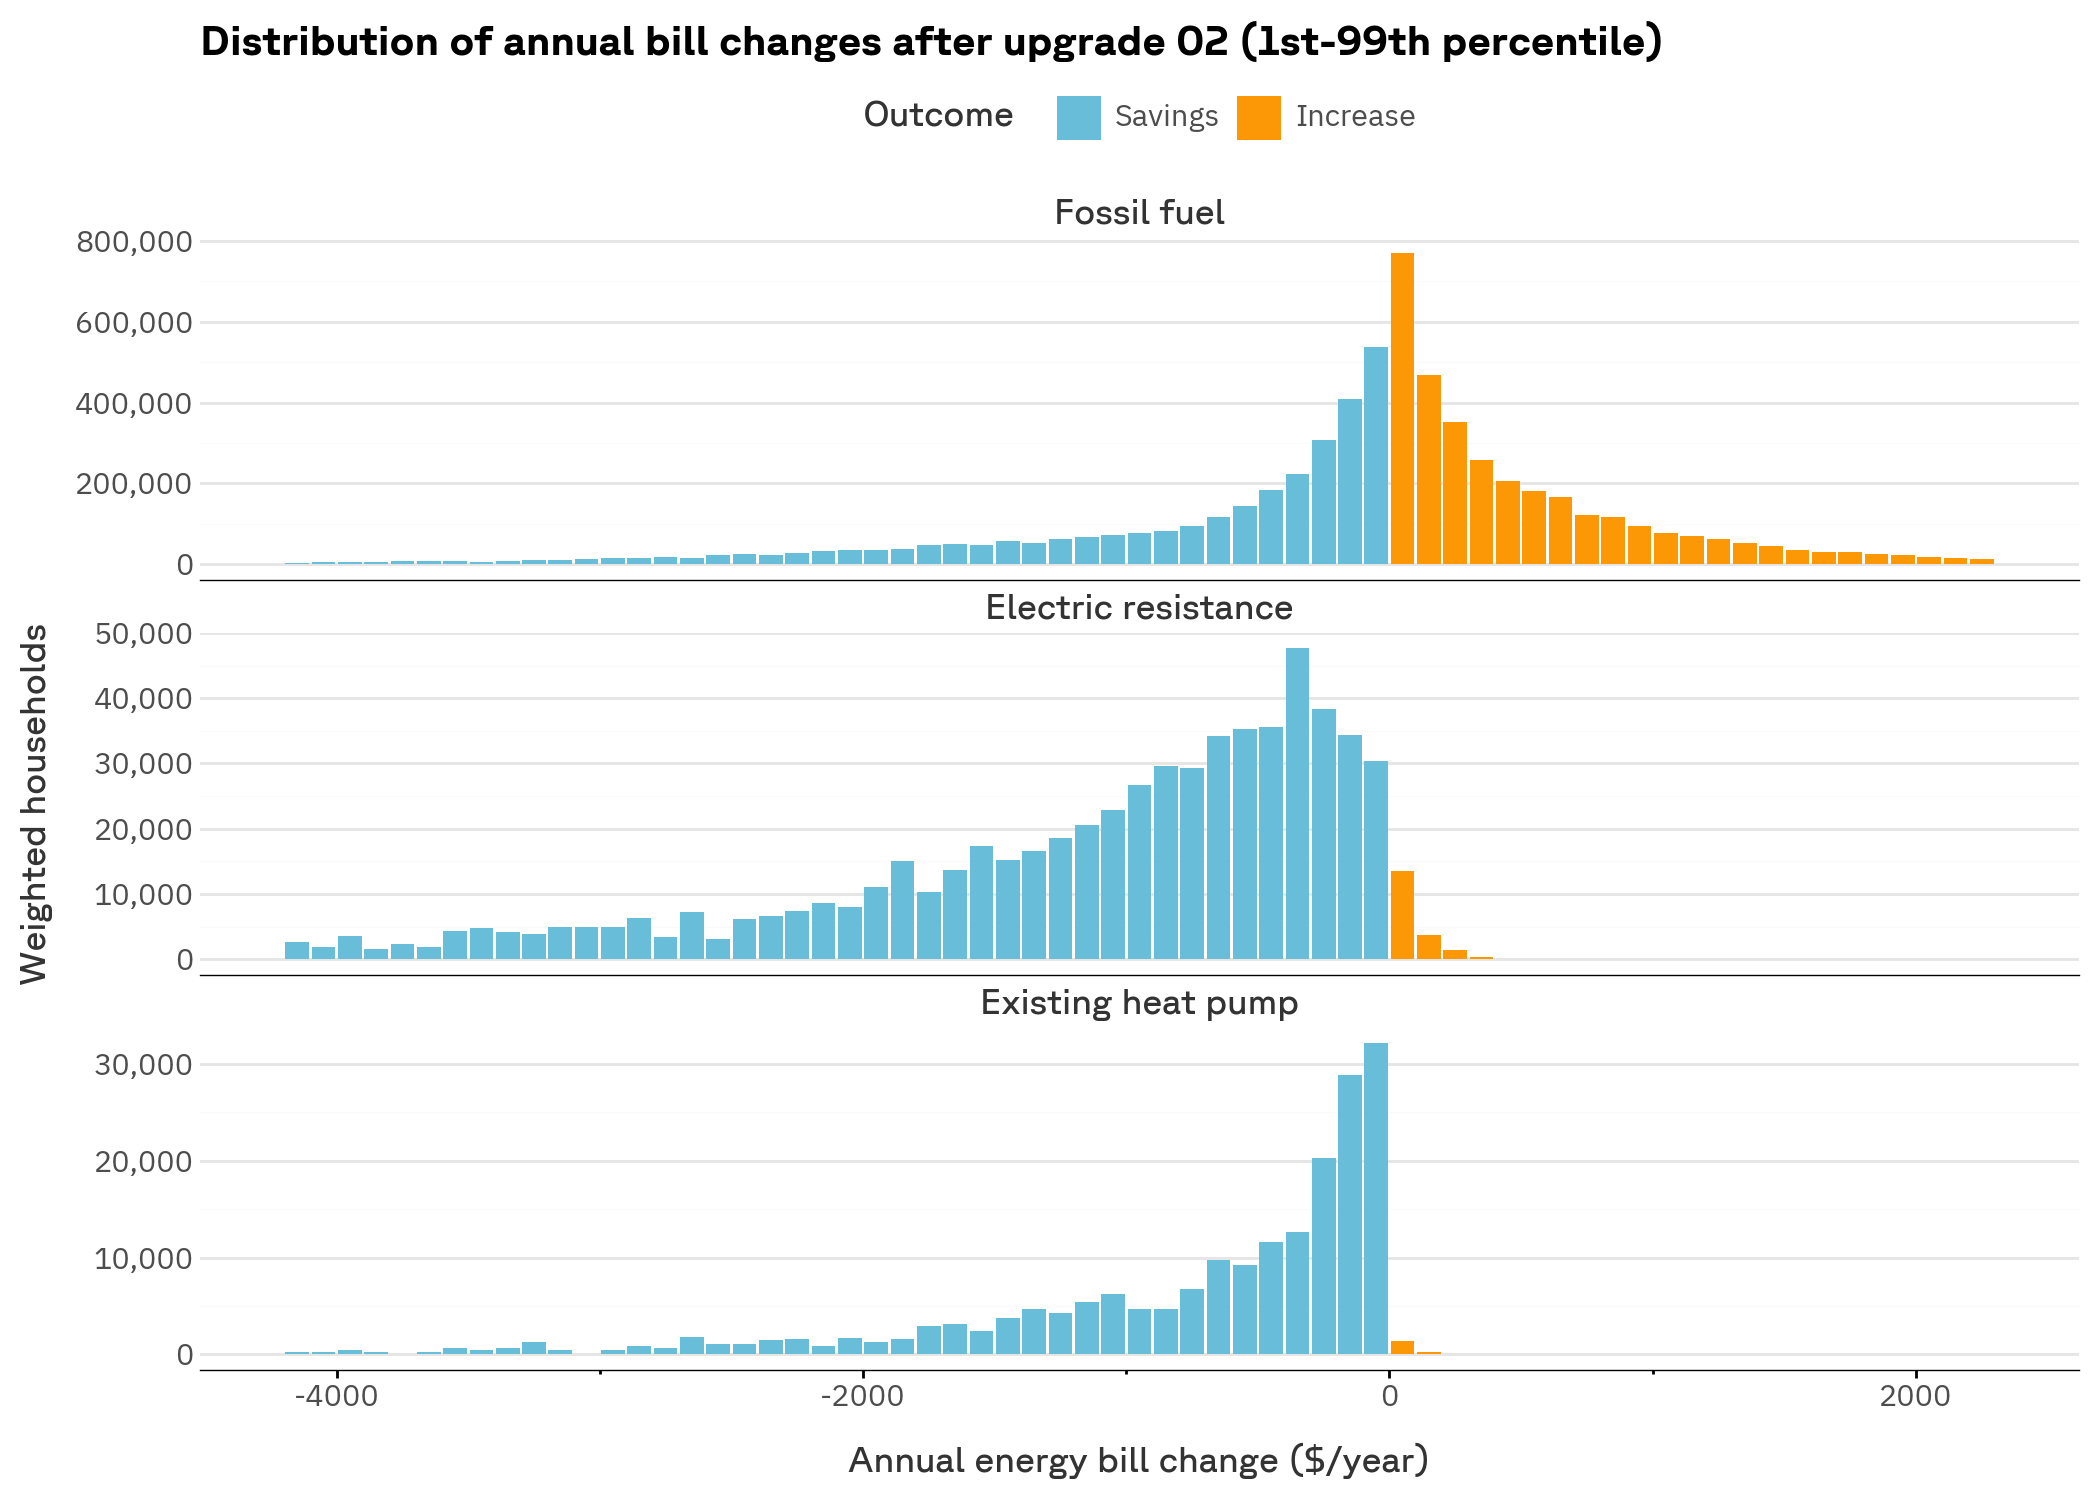

In [55]:
BIN_WIDTH = 100
_lo = math.floor(weighted_quantile(bill_delta, "delta", 0.01) / BIN_WIDTH) * BIN_WIDTH
_hi = math.ceil(weighted_quantile(bill_delta, "delta", 0.99) / BIN_WIDTH) * BIN_WIDTH

hist_data = (
    bill_delta.filter(pl.col("heating_label").is_in(avail_heating))
    .with_columns(
        ((pl.col("delta") / BIN_WIDTH).floor() * BIN_WIDTH + BIN_WIDTH / 2).alias("bin_center"),
        pl.when(pl.col("delta") < 0).then(pl.lit("Savings")).otherwise(pl.lit("Increase")).alias("direction"),
    )
    .filter(pl.col("bin_center").is_between(_lo, _hi))
    .group_by("heating_label", "bin_center", "direction")
    .agg(pl.col("weight").sum().alias("weighted_households"))
    .with_columns(
        pl.col("heating_label").cast(pl.Enum(avail_heating)),
        pl.col("direction").cast(pl.Enum(["Savings", "Increase"])),
    )
)

(
    ggplot(hist_data, aes(x="bin_center", y="weighted_households", fill="direction"))
    + geom_col(width=BIN_WIDTH * 0.9)
    + facet_wrap("heating_label", ncol=1, scales="free_y")
    + scale_fill_manual(values={"Savings": SB_COLORS["sky"], "Increase": SB_COLORS["carrot"]})
    + scale_y_continuous(labels=lambda xs: [f"{x:,.0f}" for x in xs])
    + labs(
        x="Annual energy bill change ($/year)",
        y="Weighted households",
        fill="Outcome",
        title="Distribution of annual bill changes after upgrade 02 (1st-99th percentile)",
    )
    + theme_switchbox()
    + theme(
        figure_size=(10.5, max(4.5, 2.5 * len(avail_heating))),
        legend_position="top",
    )
)

### 5d: Utility-level summary

Per-utility summary of bill-change and BAT results. Helps identify whether one
utility's results are driving state-level patterns, and flags utilities with
implausible outliers.

In [56]:
util_bat_u0 = bat_by_scenario["Upgrade 00"]
util_rows: list[dict[str, object]] = []

for utility in sorted(annual_u0[UTILITY_COL].drop_nulls().unique().to_list()):
    delta_u = bill_delta.filter(pl.col(UTILITY_COL) == utility)
    bat_u = util_bat_u0.filter(pl.col(UTILITY_COL) == utility)
    if delta_u.is_empty() or bat_u.is_empty():
        continue
    util_rows.append(
        {
            "utility": utility,
            "buildings": delta_u.height,
            "weighted_households": round(cast(float, delta_u["weight"].sum())),
            "mean_bill_change": round(weighted_mean(delta_u, "delta"), 0),
            "median_bill_change": round(weighted_quantile(delta_u, "delta", 0.5), 0),
            "pct_saving": round(
                cast(float, delta_u.filter(pl.col("delta") < 0)["weight"].sum())
                / cast(float, delta_u["weight"].sum())
                * 100,
                1,
            ),
            "mean_bat_total_u0": round(weighted_mean(bat_u, "BAT_percustomer_total"), 0),
            "pct_overpaying_u0": round(
                cast(
                    float,
                    bat_u.filter(pl.col("BAT_percustomer_total") > 0)["weight"].sum(),
                )
                / cast(float, bat_u["weight"].sum())
                * 100,
                1,
            ),
        }
    )

util_df = pl.DataFrame(util_rows)
print("Per-utility summary (upgrade 00 BAT + upgrade 00→02 bill change):")
display(util_df)

Per-utility summary (upgrade 00 BAT + upgrade 00→02 bill change):


utility,buildings,weighted_households,mean_bill_change,median_bill_change,pct_saving,mean_bat_total_u0,pct_overpaying_u0
str,i64,i64,f64,f64,f64,f64,f64
"""cenhud""",1182,270859,-721.0,-471.0,78.2,0.0,39.1
"""coned""",15435,3064038,-156.0,-69.0,59.1,-0.0,33.2
"""nimo""",6791,1532294,-44.0,150.0,36.0,-0.0,36.9
"""nyseg""",3682,792300,-242.0,0.0,47.6,0.0,35.7
"""or""",829,211011,-352.0,-124.0,63.8,0.0,41.7
"""psegli""",4427,1029955,-720.0,-332.0,70.8,-0.0,42.9
"""rge""",1444,351481,29.0,236.0,26.4,-0.0,32.8


---

## Interpretation checklist

Before using these results in a report or policy analysis:

1. **Structural checks passed** — All assertions in Section 3 must pass cleanly. A
   failure indicates a specific post-processing step to investigate.

2. **Utility coverage looks right** — Confirm that weighted household totals per
   utility (Section 2a) are stable across scenarios and plausible for the service
   territory.

3. **Heating-type breakdown is plausible** — The upgrade 00 heating-type composition
   (Section 2b) should reflect the state's known building stock. A suspiciously low
   fossil-fuel share or high heat-pump share may indicate a ResStock metadata issue.

4. **Gas null fraction makes sense** — High gas-null share is expected in all-electric
   territories; investigate if it is unexpectedly low in a gas-dense market.

5. **BAT signs are correct** — Under flat default rates, fossil-fuel customers should
   show negative BAT (they underpay); HP/ER customers should show positive BAT
   (they overpay). If this pattern is reversed, check the residual allocation
   configuration in the CAIRO scenario YAML.

6. **Cross-subsidy magnitude is reasonable** — Compare against prior state runs at
   similar utility scales to identify implausible outliers.

7. **Bill change signs match fuel-cost logic** — Fossil-fuel homes should generally
   save in warmer states (low heating loads) and see more mixed results in cold
   states with high gas demand. Oil/propane homes typically show larger savings.

8. **To review another state or batch** — Change `STATE` and `BATCH` in the
   Parameters cell, restart the kernel, and run all cells.